# EDA — NBA career outcomes (Deliverable 2)

Builds the **v1 career summary** per `progress/target_variable_spec.md`:

- Dedupe multi-team seasons (`2TM` / `3TM`).
- Run tiers **A–D**, entry cohort debuts **2011–12 … 2022–23**.
- **Composite** (tier **D** ∩ cohort): **0.70·z(fantasy mean)** + **0.30·z(log(1+r))** with **r** = games / opportunity (82 × seasons debut→panel end) — no VORP/DWS in the outcome.

Figures save to `progress/figures/`.

In [1]:
from pathlib import Path
import importlib
import sys

# Repo root on path before loading project packages (works from project root or notebooks/).
_cands = [Path(".").resolve(), Path("..").resolve(), Path.cwd()]
ROOT = next(p for p in _cands if (p / "data" / "processed" / "model_base_player_season.csv").exists())
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

plt = importlib.import_module("matplotlib.pyplot")
np = importlib.import_module("numpy")
pd = importlib.import_module("pandas")
sns = importlib.import_module("seaborn")
_co = importlib.import_module("src.analysis.career_outcomes")
importlib.reload(_co)  # pick up edits to career_outcomes.py without kernel restart
build_player_career_summary = _co.build_player_career_summary
dedupe_nba_player_season = _co.dedupe_nba_player_season

PROC = ROOT / "data" / "processed"
FIG = ROOT / "progress" / "figures"
FIG.mkdir(parents=True, exist_ok=True)

sns.set_theme(style="whitegrid", context="notebook")

mb = pd.read_csv(PROC / "model_base_player_season.csv")
ded = dedupe_nba_player_season(mb)
assert ded.groupby(["nba_player_id", "Season"]).size().max() == 1, "dedupe: one row per player-season"

summ = build_player_career_summary(mb)
summ.to_csv(PROC / "player_career_summary_v1.csv", index=False)
print("Players:", len(summ))
print("Tier counts:\n", summ["nba_run_tier"].value_counts().sort_index())
print("Entry cohort (any tier):", summ["entry_cohort"].sum())
print("Composite non-null (D ∩ cohort):", summ["success_composite_v1"].notna().sum())

Players: 1812
Tier counts:
 nba_run_tier
B     305
C     237
D    1270
Name: count, dtype: int64
Entry cohort (any tier): 1128
Composite non-null (D ∩ cohort): 713


In [2]:
# Top / bottom players by composite (tier D ∩ cohort only) — sanity check
app = pd.read_csv(PROC / "nba_season_appearances.csv")
names = app.drop_duplicates(subset=["nba_player_id"], keep="last")[
    ["nba_player_id", "player_name"]
]
cols = [
    "nba_player_id",
    "success_composite_v1",
    "z_fantasy",
    "z_longevity",
    "mean_fp_per_game_qual",
    "career_games",
    "first_season",
]
cols = [c for c in cols if c in summ.columns]
top = (
    summ.loc[summ["success_composite_v1"].notna(), cols]
    .merge(names, on="nba_player_id", how="left")
    .sort_values("success_composite_v1", ascending=False)
)
print("Top 25 by success_composite_v1:\n")
print(top.head(525).to_string(index=False))
print("\nBottom 10 by success_composite_v1:\n")
print(top.nsmallest(10, "success_composite_v1").to_string(index=False))

Top 25 by success_composite_v1:

nba_player_id  success_composite_v1  z_fantasy  z_longevity  mean_fp_per_game_qual  career_games first_season              player_name
    jokicni01              3.341430   4.082592     1.612051              52.992771         803.0      2015-16             Nikola Jokić
    doncilu01              3.253582   4.103188     1.271167              53.175177         511.0      2018-19              Luka Dončić
    antetgi01              2.885339   3.496440     1.459435              47.801483         895.0      2013-14    Giannis Antetokounmpo
    davisan02              2.877568   3.671155     1.025866              49.348852         807.0      2012-13            Anthony Davis
    gilgesh01              2.680043   3.259215     1.328643              45.700482         523.0      2018-19  Shai Gilgeous-Alexander
    embiijo01              2.604076   3.441651     0.649733              47.316237         486.0      2016-17              Joel Embiid
    townska01         

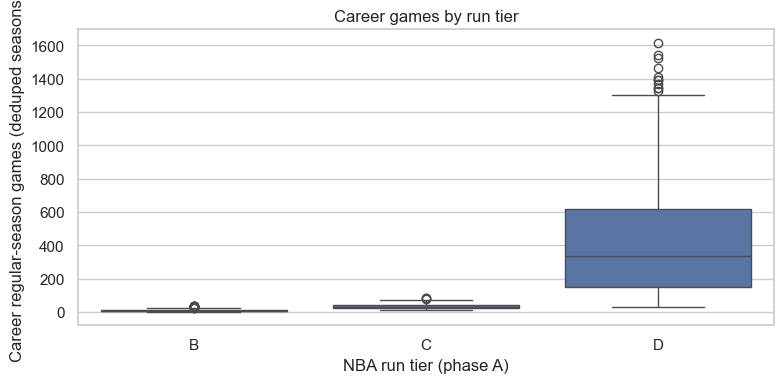

In [3]:
# Tier B/C/D: career games (shows fringe vs established)
plot_df = summ[summ["nba_run_tier"].isin(["B", "C", "D"])].copy()
fig, ax = plt.subplots(figsize=(8, 4))
sns.boxplot(data=plot_df, x="nba_run_tier", y="career_games", order=["B", "C", "D"], ax=ax)
ax.set_xlabel("NBA run tier (phase A)")
ax.set_ylabel("Career regular-season games (deduped seasons)")
ax.set_title("Career games by run tier")
fig.tight_layout()
fig.savefig(FIG / "eda_tier_career_games.png", dpi=150)
plt.show()

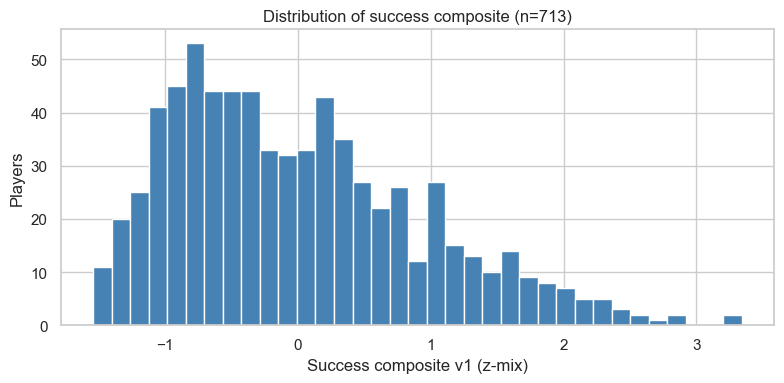

count    7.130000e+02
mean     1.993107e-17
std      9.409927e-01
min     -1.543256e+00
25%     -7.486916e-01
50%     -1.550850e-01
75%      5.748408e-01
max      3.341430e+00
Name: success_composite_v1, dtype: float64

In [4]:
# Primary outcome: composite distribution (tier D + entry cohort only)
comp = summ["success_composite_v1"].dropna()
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(comp, bins=35, color="steelblue", edgecolor="white")
ax.set_xlabel("Success composite v1 (z-mix)")
ax.set_ylabel("Players")
ax.set_title(f"Distribution of success composite (n={len(comp)})")
fig.tight_layout()
fig.savefig(FIG / "eda_success_composite_hist.png", dpi=150)
plt.show()
comp.describe()

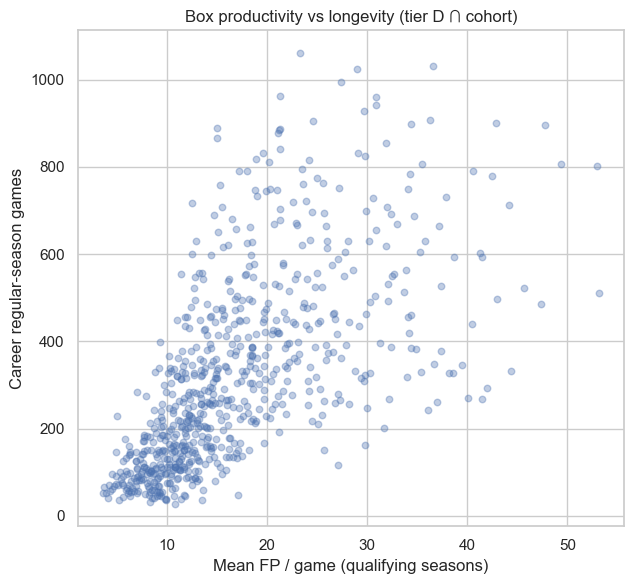

In [5]:
# Bivariate: fantasy rate vs career games (tier D ∩ cohort)
elig = summ[summ["success_composite_v1"].notna()].copy()
fig, ax = plt.subplots(figsize=(6.5, 6))
ax.scatter(elig["mean_fp_per_game_qual"], elig["career_games"], alpha=0.35, s=22)
ax.set_xlabel("Mean FP / game (qualifying seasons)")
ax.set_ylabel("Career regular-season games")
ax.set_title("Box productivity vs longevity (tier D ∩ cohort)")
fig.tight_layout()
fig.savefig(FIG / "eda_fp_vs_career_games.png", dpi=150)
plt.show()

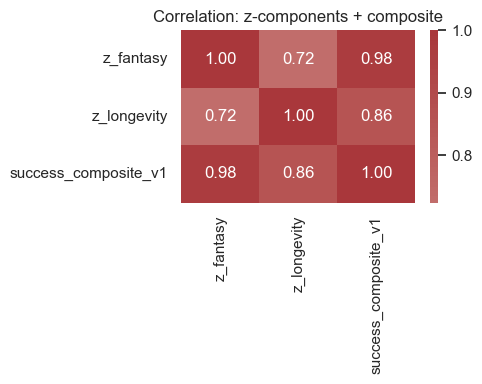

In [6]:
# Correlation: z-fantasy, z-longevity, composite (eligible only)
zcols = ["z_fantasy", "z_longevity", "success_composite_v1"]
cm = elig[zcols].corr()
fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt=".2f", cmap="vlag", center=0, ax=ax)
ax.set_title("Correlation: z-components + composite")
fig.tight_layout()
fig.savefig(FIG / "eda_z_correlation.png", dpi=150)
plt.show()